In [2]:
import re
import html
import zipfile
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from lemminflect import getLemma
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from IPython.display import display, Markdown
from functools import lru_cache

In [3]:
SEED = 42
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", None)

## 02. Part A — Dataset description and loading
IMDb is a binary movie-review sentiment dataset. The uploaded CSV is the source used here; it is not redistributed inside this notebook.

In [4]:
candidates = [Path("IMDB Dataset.csv"), Path("archive (3).zip"), Path("upload/IMDB Dataset.csv"), Path("upload/archive (3).zip")]
data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Place IMDB Dataset.csv or archive (3).zip beside the notebook.")
if data_path.suffix == ".zip":
    with zipfile.ZipFile(data_path) as archive:
        csv_name = next(name for name in archive.namelist() if name.endswith(".csv"))
        with archive.open(csv_name) as file:
            df = pd.read_csv(file)
else:
    df = pd.read_csv(data_path)

In [5]:
print("Records:", len(df))
print("Columns:", df.shape[1])
print("Column names:", df.columns.tolist())
display(df.head(10))
display(df.dtypes.rename("Data type").to_frame())

Records: 50000
Columns: 2
Column names: ['review', 'sentiment']


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first ...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of rea...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be ...",positive
5,"Probably my all-time favorite movie, a story of selflessness, sacrifice and dedication to a noble cause, but it's not preachy or boring. It just never gets old, despite my havi...",positive
6,I sure would like to see a resurrection of a up dated Seahunt series with the tech they have today it would bring back the kid excitement in me.I grew up on black and white TV ...,positive
7,"This show was an amazing, fresh & innovative idea in the 70's when it first aired. The first 7 or 8 years were brilliant, but things dropped off after that. By 1990, the show w...",negative
8,Encouraged by the positive comments about this film on here I was looking forward to watching this film. Bad mistake. I've seen 950+ films and this is truly one of the worst of...,negative
9,"If you like original gut wrenching laughter you will like this movie. If you are young or old then you will love this movie, hell even my mom liked it.<br /><br />Great Camp!!!",positive


,Data type
review,object
sentiment,object


In [6]:
display(df.isna().sum().rename("Missing values").to_frame())
print("Duplicate reviews:", df.duplicated(subset="review").sum())
print("Empty reviews:", df["review"].fillna("").str.strip().eq("").sum())
display(df["sentiment"].value_counts(dropna=False).to_frame("Count"))
display(df["sentiment"].value_counts(normalize=True).mul(100).to_frame("Percent"))

Duplicate reviews: 418
Empty reviews: 0


,Missing values
review,0
sentiment,0


,Count
sentiment,
positive,25000
negative,25000


,Percent
sentiment,
positive,50.0
negative,50.0


In [7]:
df["word_count"] = df["review"].fillna("").str.split().str.len()
display(df.nlargest(10, "word_count")[["review", "sentiment", "word_count"]])
display(df.nsmallest(10, "word_count")[["review", "sentiment", "word_count"]])

,review,sentiment,word_count
31481,Match 1: Tag Team Table Match Bubba Ray and Spike Dudley vs Eddie Guerrero and Chris Benoit Bubba Ray and Spike Dudley started things off with a Tag Team Table Match against Ed...,positive,2470
40521,"There's a sign on The Lost Highway that says:<br /><br />*MAJOR SPOILERS AHEAD*<br /><br />(but you already knew that, didn't you?)<br /><br />Since there's a great deal of peo...",positive,2278
31436,"Back in the mid/late 80s, an OAV anime by title of ""Bubblegum Crisis"" (which I think is a military slang term for when technical equipment goes haywire) made its debut on video...",positive,2125
31240,"(Some spoilers included:)<br /><br />Although, many commentators have called this film surreal, the term fits poorly here. To quote from Encyclopedia Britannica's, surreal mean...",positive,2108
12647,"Titanic directed by James Cameron presents a fictional love story on the historical setting of the Titanic. The plot is simple, noncomplicated, or not for those who love plots ...",positive,1839
5708,"**Attention Spoilers**<br /><br />First of all, let me say that Rob Roy is one of the best films of the 90's. It was an amazing achievement for all those involved, especially t...",positive,1830
3024,"If anyone ever assembles a compendium on modern American horror that is truly worth it's salt, there will *have* to be an entry for SF Brownrigg's ubiquetous exercize in Asylum...",positive,1737
42946,"By now you've probably heard a bit about the new Disney dub of Miyazaki's classic film, Laputa: Castle In The Sky. During late summer of 1998, Disney released ""Kiki's Delivery ...",positive,1723
3654,"*!!- SPOILERS - !!*<br /><br />Before I begin this, let me say that I have had both the advantages of seeing this movie on the big screen and of having seen the ""Authorized Ver...",positive,1601
1531,"Warning: Does contain spoilers.<br /><br />Open Your Eyes<br /><br />If you have not seen this film and plan on doing so, just stop reading here and take my word for it. You ha...",positive,1527


,review,sentiment,word_count
28920,Primary plot!Primary direction!Poor interpretation.,negative,4
27521,"Read the book, forget the movie!",negative,6
13109,"More suspenseful, more subtle, much, much more disturbing....",negative,8
40817,I hope this group of film-makers never re-unites.,negative,8
31072,"What a script, what a story, what a mess!",negative,9
11926,I wouldn't rent this one even on dollar rental night.,negative,10
18400,Brilliant and moving performances by Tom Courtenay and Peter Finch.,positive,10
19874,This movie is terrible but it has some good effects.,negative,10
20274,You'd better choose Paul Verhoeven's even if you have watched it.,negative,11
31761,Ming The Merciless does a little Bardwork and a movie most foul!,negative,12


In [8]:
df = df.dropna(subset=["review", "sentiment"]).copy()
df = df[df["review"].str.strip().ne("")].copy()
df["sentiment"] = df["sentiment"].str.lower().str.strip()
assert set(df["sentiment"]) == {"negative", "positive"}
df["review_key"] = df["review"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
conflicts = df.groupby("review_key")["sentiment"].nunique()
conflict_keys = conflicts[conflicts > 1].index
print("Conflicting review groups removed:", len(conflict_keys))
df = df[~df["review_key"].isin(conflict_keys)].drop_duplicates("review_key").reset_index(drop=True)
print("Usable records:", len(df))
display(df["sentiment"].value_counts().to_frame("Count after cleanup"))

Conflicting review groups removed: 0
Usable records: 49582


,Count after cleanup
sentiment,
positive,24884
negative,24698


**Dataset questions:** The original dataset has equal positive and negative class counts; the displayed counts verify whether this remains approximately true after cleanup. A dominant class can make accuracy misleading: a majority-only model may look accurate while missing most minority examples. Precision, recall, macro-F1, and stratified splitting help assess this. Duplicate reviews must be removed before splitting because the same text in training and testing can inflate results. Conflicting labels for identical normalized reviews are removed rather than arbitrarily keeping one.

## 03. Part B — Reusable text preprocessing
Keep `not`, `no`, `never`, and `nor`: they can reverse sentiment. Expand common negative contractions before punctuation removal. Use lemmatization for the main comparison, and measure alternatives later.

In [9]:
tokenizer = RegexpTokenizer(r"[a-z]+")
stop_words = set(ENGLISH_STOP_WORDS) - {"not", "no", "never", "nor"}
stemmer = PorterStemmer()

In [10]:
def basic_tokens(text):
    text = html.unescape(str(text)).lower().replace("’", "'")
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.replace("won't", "will not").replace("can't", "can not")
    text = text.replace("ain't", "is not")
    text = re.sub(r"n't\b", " not", text)
    return tokenizer.tokenize(text)

In [11]:
@lru_cache(maxsize=200000)
def lemma_word(word):
    return getLemma(word, upos="NOUN")[0]
@lru_cache(maxsize=200000)
def stem_word(word):
    return stemmer.stem(word)
def preprocess_text(text, remove_stopwords=True, normalization="lemma"):
    words = basic_tokens(text)
    if remove_stopwords:
        words = [word for word in words if word not in stop_words]
    if normalization == "stem":
        words = [stem_word(word) for word in words]
    elif normalization == "lemma":
        words = [lemma_word(word) for word in words]
    return " ".join(words)

The simple production lemmatizer uses Lemminflect’s noun form. This avoids a slow tagger, but it does not correctly normalize every verb or adjective. Part D shows how supplying the part of speech improves those examples. Alphabetic tokenization removes punctuation, digits, and special characters, which can also discard useful ratings and emoticons. For example, treating `does` as a noun can produce `doe`; a POS-aware lemmatizer would avoid this mistake.

In [12]:
df["cleaned_text"] = df["review"].map(preprocess_text)
display(df[["review", "cleaned_text"]].head(10).rename(columns={"review": "Original Text", "cleaned_text": "Cleaned Text"}))
print("Empty after preprocessing:", df["cleaned_text"].eq("").sum())
df = df[df["cleaned_text"].ne("")].copy()
clean_conflicts = df.groupby("cleaned_text")["sentiment"].nunique()
df = df[~df["cleaned_text"].isin(clean_conflicts[clean_conflicts > 1].index)]
df = df.drop_duplicates("cleaned_text").reset_index(drop=True)
print("Final records after cleaned-text duplicate checks:", len(df))

Empty after preprocessing: 0
Final records after cleaned-text duplicate checks: 49574


,Original Text,Cleaned Text
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first ...",reviewer mentioned watching just oz episode ll hook right exactly happened thing struck oz brutality unflinching scene violence set right word trust not faint heart timid pull ...
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of rea...",wonderful little production filming technique unassuming old time bbc fashion give comforting discomforting sense realism entire piece actor extremely chosen michael sheen not ...
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic...",thought wonderful way spend time hot summer weekend sitting air conditioned theater watching light heart comedy plot simplistic dialogue witty character likable bread suspected...
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap ...,basically family little boy jake think zombie closet parent fighting time movie slower soap opera suddenly jake decide rambo kill zombie ok going make film decide thriller dr...
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be ...",petter matteus love time money visually stunning film watch mr matteus offer vivid portrait human relation movie telling money power success people different situation encount...
5,"Probably my all-time favorite movie, a story of selflessness, sacrifice and dedication to a noble cause, but it's not preachy or boring. It just never gets old, despite my havi...",probably time favorite movie story selflessness sacrifice dedication noble cause not preachy boring just never get old despite having seen time year paul luka performance brin...
6,I sure would like to see a resurrection of a up dated Seahunt series with the tech they have today it would bring back the kid excitement in me.I grew up on black and white TV ...,sure like resurrection dated seahunt series tech today bring kid excitement grew black white tv seahunt gunsmoke hero week vote comeback new sea hunt need change pace tv work ...
7,"This show was an amazing, fresh & innovative idea in the 70's when it first aired. The first 7 or 8 years were brilliant, but things dropped off after that. By 1990, the show w...",amazing fresh innovative idea aired year brilliant thing dropped not really funny anymore continued decline complete waste time today truly disgraceful far fallen writing pa...
8,Encouraged by the positive comments about this film on here I was looking forward to watching this film. Bad mistake. I've seen 950+ films and this is truly one of the worst of...,encouraged positive comment film looking forward watching film bad mistake ve seen film truly worst awful way editing pacing storyline acting soundtrack film song lame countr...
9,"If you like original gut wrenching laughter you will like this movie. If you are young or old then you will love this movie, hell even my mom liked it.<br /><br />Great Camp!!!",like original gut wrenching laughter like movie young old love movie hell mom liked great camp


**Sentiment versus topic classification:** Sentiment needs negation, emotional modifiers, and sometimes punctuation or emoji. Topic classification may benefit more from entity names and subject nouns, and can often remove more function words. Neither task should use an untested stopword list blindly.

## 04. Part C — Tokenization and stopword analysis
These full-corpus counts are descriptive EDA only; they do not define model vocabularies or select features.

In [13]:
before_counts = Counter()
after_counts = Counter()
for review in df["review"]:
    words = basic_tokens(review)
    before_counts.update(words)
    after_counts.update(word for word in words if word not in stop_words)

In [14]:
token_summary = pd.DataFrame({
    "Before stopword removal": [sum(before_counts.values()), len(before_counts), sum(before_counts.values()) / len(df)],
    "After stopword removal": [sum(after_counts.values()), len(after_counts), sum(after_counts.values()) / len(df)]
}, index=["Total tokens", "Unique tokens", "Average tokens per document"])
display(token_summary)
display(pd.DataFrame(before_counts.most_common(20), columns=["Word", "Count"]))
display(pd.DataFrame(after_counts.most_common(20), columns=["Word", "Count"]))

,Before stopword removal,After stopword removal
Total tokens,1.161893e+07,5.541929e+06
Unique tokens,9.928200e+04,9.897200e+04
Average tokens per document,2.343756e+02,1.117910e+02


,Word,Count
0,the,662848
1,and,322057
2,a,320773
3,of,287323
4,to,266099
5,is,216234
6,it,189422
7,in,185385
8,i,174117
9,this,149792


,Word,Count
0,s,128900
1,not,126196
2,movie,87262
3,film,79140
4,like,39841
5,just,34925
6,good,29537
7,no,25083
8,time,24902
9,story,22969


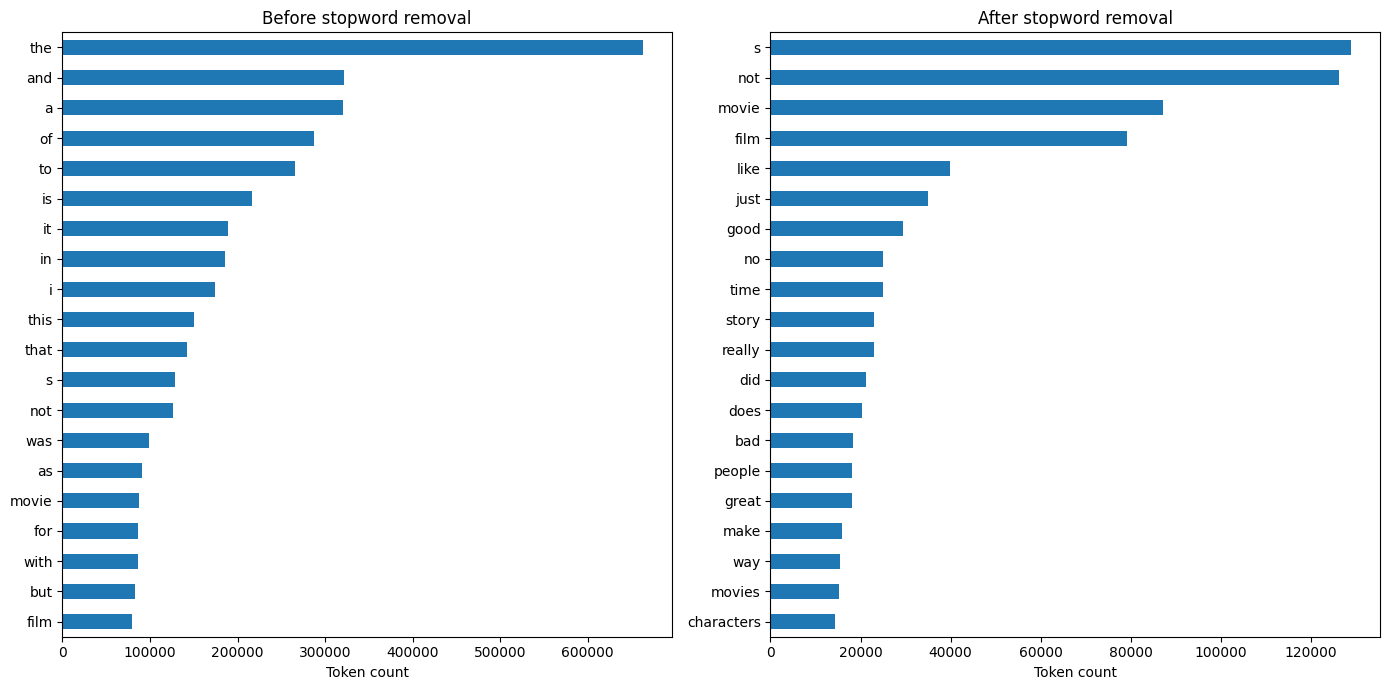

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, counts, title in zip(axes, [before_counts, after_counts], ["Before stopword removal", "After stopword removal"]):
    top = pd.Series(dict(counts.most_common(20))).sort_values()
    top.plot.barh(ax=ax, title=title)
    ax.set_xlabel("Token count")
plt.tight_layout()
plt.show()

Before removal, grammatical words occupy many of the top positions. After removal, movie-related and evaluative words become more visible. Counts and average document length decrease; preserved negation remains available. Frequency changes alone do not prove a classification improvement; the validation ablation below tests that. The surviving token `s` is a contraction/possessive fragment, showing a limitation of this simple tokenizer and stopword list.

## 05. Part D — Stemming versus lemmatization

In [16]:
example_words = ["studies", "studying", "running", "better", "computers", "movies", "children", "mice", "feet", "went", "cars", "happily", "easily", "playing", "played", "leaves", "wolves", "worse", "amazing", "loved", "actors", "boxes", "was", "stories"]
example_pos = ["n", "v", "v", "a", "n", "n", "n", "n", "n", "v", "n", "r", "r", "v", "v", "n", "n", "a", "v", "v", "n", "n", "v", "n"]
display(pd.DataFrame({"Original": example_words, "Stemmed": [stemmer.stem(w) for w in example_words], "Lemmatized": [getLemma(w, upos={"n": "NOUN", "v": "VERB", "a": "ADJ", "r": "ADV"}[p])[0] for w, p in zip(example_words, example_pos)]}))

,Original,Stemmed,Lemmatized
0,studies,studi,study
1,studying,studi,study
2,running,run,run
3,better,better,good
4,computers,comput,computer
5,movies,movi,movie
6,children,children,child
7,mice,mice,mouse
8,feet,feet,foot
9,went,went,go


Stemming strips endings using rules and can produce fragments such as `studi`. Lemmatization uses a dictionary and grammatical information to return meaningful forms such as `study`, `run`, and `good`. Lemmatization is the main pipeline choice because its features are easier to interpret. This is a readability choice, not an assumed accuracy advantage: stemming, lemmatization, and no normalization are compared on validation data.

## 06. Part E — Unigrams, bigrams, and trigrams

In [17]:
ngram_counts = {1: Counter(), 2: Counter(), 3: Counter()}
for text in df["cleaned_text"]:
    words = text.split()
    for n in [1, 2, 3]:
        ngram_counts[n].update(" ".join(words[i:i + n]) for i in range(len(words) - n + 1))

In [18]:
for n in [1, 2, 3]:
    print(f"Top 20 {n}-grams")
    display(pd.DataFrame(ngram_counts[n].most_common(20), columns=["N-gram", "Count"]))

Top 20 1-grams
Top 20 2-grams
Top 20 3-grams


,N-gram,Count
0,not,126201
1,movie,102483
2,film,92805
3,like,40786
4,just,34926
5,time,31205
6,good,29652
7,character,28119
8,story,25108
9,no,25089


,N-gram,Count
0,doe not,11444
1,did not,11065
2,movie not,4395
3,ve seen,3880
4,not know,3607
5,look like,3592
6,film not,3318
7,not really,2599
8,year old,2361
9,special effect,2312


,N-gram,Count
0,movie ve seen,682
1,movie doe not,681
2,did not know,619
3,doe not make,580
4,did not like,569
5,not waste time,554
6,film doe not,544
7,m not sure,518
8,just did not,479
9,film ve seen,464


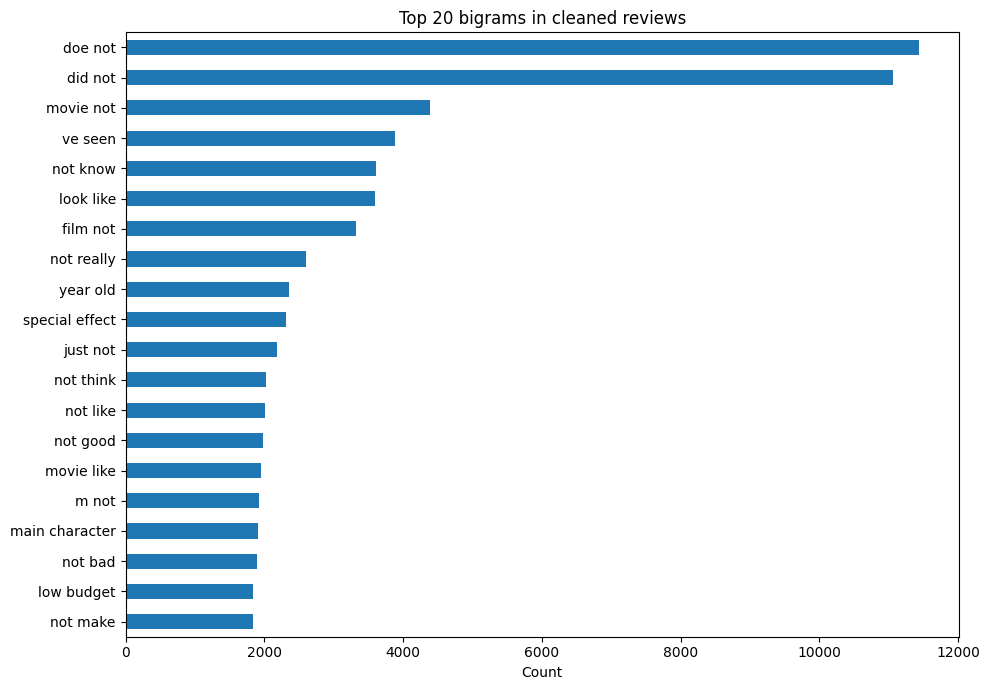

In [19]:
pd.Series(dict(ngram_counts[2].most_common(20))).sort_values().plot.barh(figsize=(10, 7))
plt.title("Top 20 bigrams in cleaned reviews")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

Bigrams preserve local order, so `not good` expresses something that independent counts of `not` and `good` cannot. Larger n-grams create many rare features, increase memory and sparsity, and generalize poorly to unseen wording. Removing stopwords can create artificial neighbors: these n-grams describe the cleaned token stream, not always exact original phrases.

## 07. Shared 80/20 train–test split

In [20]:
train_idx, test_idx = train_test_split(df.index, test_size=0.20, random_state=SEED, stratify=df["sentiment"])
fit_idx, val_idx = train_test_split(train_idx, test_size=0.20, random_state=SEED, stratify=df.loc[train_idx, "sentiment"])
y_train = df.loc[train_idx, "sentiment"]
y_test = df.loc[test_idx, "sentiment"]
y_fit = df.loc[fit_idx, "sentiment"]
y_val = df.loc[val_idx, "sentiment"]
print("Full training:", len(train_idx), "Testing:", len(test_idx))
print("Inner fitting:", len(fit_idx), "Validation:", len(val_idx))
display(pd.DataFrame({"Train": y_train.value_counts(normalize=True), "Validation": y_val.value_counts(normalize=True), "Test": y_test.value_counts(normalize=True)}))

Full training: 39659 Testing: 9915
Inner fitting: 31727 Validation: 7932


,Train,Validation,Test
sentiment,,,
positive,0.501853,0.501891,0.501866
negative,0.498147,0.498109,0.498134


## 08. Parts F and G — Bag-of-Words and TF-IDF
Each method uses a maximum of 5,000 features. Compare unigrams against unigrams plus bigrams on identical splits.

In [21]:
def make_vectorizer(name):
    ngram_range = (1, 2) if "Bigrams" in name else (1, 1)
    vectorizer_class = TfidfVectorizer if name.startswith("TF-IDF") else CountVectorizer
    return vectorizer_class(max_features=5000, ngram_range=ngram_range)
representations = ["BoW Unigrams", "BoW Unigrams + Bigrams", "TF-IDF Unigrams", "TF-IDF Unigrams + Bigrams"]

TF-IDF reduces the influence of terms that occur in many documents through inverse document frequency. With scikit-learn’s smoothed formula, a term in every document has IDF 1, not 0; it receives no rarity boost. TF-IDF works well with linear classifiers because discriminative terms can receive useful weights in a sparse, high-dimensional space.

## 09. Part H — Logistic Regression, Multinomial Naive Bayes, and Linear SVM

In [22]:
def make_model(name):
    if name == "Logistic Regression":
        return LogisticRegression(max_iter=1000, solver="liblinear", random_state=SEED)
    if name == "Naive Bayes":
        return MultinomialNB()
    return LinearSVC(dual=False, max_iter=5000, random_state=SEED)
model_names = ["Logistic Regression", "Naive Bayes", "Linear SVM"]

In [23]:
def scores(actual, predicted):
    return {"Accuracy": accuracy_score(actual, predicted), "Precision": precision_score(actual, predicted, pos_label="positive", zero_division=0), "Recall": recall_score(actual, predicted, pos_label="positive", zero_division=0), "F1": f1_score(actual, predicted, pos_label="positive", zero_division=0), "Macro F1": f1_score(actual, predicted, average="macro")}
validation_rows = []

In [24]:
for representation in representations:
    vectorizer = make_vectorizer(representation)
    X_fit = vectorizer.fit_transform(df.loc[fit_idx, "cleaned_text"])
    X_val = vectorizer.transform(df.loc[val_idx, "cleaned_text"])
    for model_name in model_names:
        model = make_model(model_name)
        model.fit(X_fit, y_fit)
        fit_scores = scores(y_fit, model.predict(X_fit))
        val_scores = scores(y_val, model.predict(X_val))
        validation_rows.append({"Representation": representation, "Model": model_name, "Features": X_fit.shape[1], "Train Accuracy": fit_scores["Accuracy"], "Train F1": fit_scores["F1"], "Validation Accuracy": val_scores["Accuracy"], "Validation F1": val_scores["F1"]})
    print("Completed validation:", representation)

Completed validation: BoW Unigrams
Completed validation: BoW Unigrams + Bigrams
Completed validation: TF-IDF Unigrams
Completed validation: TF-IDF Unigrams + Bigrams


In [25]:
validation_results = pd.DataFrame(validation_rows).sort_values("Validation F1", ascending=False).reset_index(drop=True)
display(validation_results.round(4))
best_representation = validation_results.loc[0, "Representation"]
best_model_name = validation_results.loc[0, "Model"]
print("Chosen using validation F1:", best_representation, "/", best_model_name)

Chosen using validation F1: TF-IDF Unigrams + Bigrams / Logistic Regression


,Representation,Model,Features,Train Accuracy,Train F1,Validation Accuracy,Validation F1
0,TF-IDF Unigrams + Bigrams,Logistic Regression,5000,0.9180,0.9192,0.8822,0.8838
1,TF-IDF Unigrams,Logistic Regression,5000,0.9138,0.9150,0.8806,0.8823
2,TF-IDF Unigrams + Bigrams,Linear SVM,5000,0.9397,0.9403,0.8744,0.8755
3,TF-IDF Unigrams,Linear SVM,5000,0.9363,0.9369,0.8694,0.8701
4,BoW Unigrams + Bigrams,Logistic Regression,5000,0.9511,0.9514,0.8627,0.8637
5,BoW Unigrams,Logistic Regression,5000,0.9478,0.9482,0.8603,0.8608
6,TF-IDF Unigrams + Bigrams,Naive Bayes,5000,0.8670,0.8696,0.8522,0.8552
7,TF-IDF Unigrams,Naive Bayes,5000,0.8654,0.8669,0.8488,0.8509
8,BoW Unigrams + Bigrams,Linear SVM,5000,0.9521,0.9524,0.8480,0.8485
9,BoW Unigrams,Linear SVM,5000,0.9478,0.9481,0.8457,0.8458


## 10. Preprocessing ablation
Hold TF-IDF unigram+bigrams and Logistic Regression fixed. Change one preprocessing step at a time using the same fitting/validation rows. Test data is not used here. These controlled comparisons support the final analysis; they do not alter the main model grid after testing.

In [26]:
variants = {"Raw text": None, "Basic cleaning only": (False, "none"), "Cleaning + stopwords": (True, "none"), "Cleaning + stopwords + stemming": (True, "stem"), "Cleaning + stopwords + lemmatization": (True, "lemma")}
ablation_rows = []

In [27]:
for name, settings in variants.items():
    if settings is None:
        fit_text = df.loc[fit_idx, "review"]
        val_text = df.loc[val_idx, "review"]
    else:
        remove, normalization = settings
        fit_text = df.loc[fit_idx, "review"].map(lambda t: preprocess_text(t, remove, normalization))
        val_text = df.loc[val_idx, "review"].map(lambda t: preprocess_text(t, remove, normalization))
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), lowercase=False)
    X_fit = vectorizer.fit_transform(fit_text)
    X_val = vectorizer.transform(val_text)
    model = make_model("Logistic Regression")
    model.fit(X_fit, y_fit)
    result = scores(y_val, model.predict(X_val))
    ablation_rows.append({"Preprocessing": name, "Validation Accuracy": result["Accuracy"], "Validation F1": result["F1"]})
    print("Completed:", name)
ablation_results = pd.DataFrame(ablation_rows)
display(ablation_results.round(4))

Completed: Raw text
Completed: Basic cleaning only
Completed: Cleaning + stopwords
Completed: Cleaning + stopwords + stemming
Completed: Cleaning + stopwords + lemmatization


,Preprocessing,Validation Accuracy,Validation F1
0,Raw text,0.8850,0.8865
1,Basic cleaning only,0.8917,0.8930
2,Cleaning + stopwords,0.8826,0.8846
3,Cleaning + stopwords + stemming,0.8833,0.8849
4,Cleaning + stopwords + lemmatization,0.8822,0.8838


The raw baseline retains case and HTML-like tokens; vectorization still tokenizes text and ignores most punctuation. Thus “raw” is not a character-level model. These are single-split comparisons without confidence intervals, so small differences should not be treated as decisive.

## 11. Part I — Model comparison on held-out testing data
Refit every fixed candidate on the same full 80% training portion. The best model remains the earlier validation winner; do not switch models based on test scores. Positive is the positive class for precision, recall, and F1.

In [28]:
test_rows = []
fitted_pipelines = {}
for representation in representations:
    vectorizer = make_vectorizer(representation)
    X_train = vectorizer.fit_transform(df.loc[train_idx, "cleaned_text"])
    X_test = vectorizer.transform(df.loc[test_idx, "cleaned_text"])
    for model_name in model_names:
        model = make_model(model_name)
        model.fit(X_train, y_train)
        predicted = model.predict(X_test)
        test_rows.append({"Representation": representation, "Model": model_name, "Final Features": X_train.shape[1], **scores(y_test, predicted)})
        fitted_pipelines[(representation, model_name)] = Pipeline([("vectorizer", vectorizer), ("model", model)])
    print("Completed test evaluation:", representation)

Completed test evaluation: BoW Unigrams
Completed test evaluation: BoW Unigrams + Bigrams
Completed test evaluation: TF-IDF Unigrams
Completed test evaluation: TF-IDF Unigrams + Bigrams


In [29]:
test_results = pd.DataFrame(test_rows)
comparison = validation_results.merge(test_results, on=["Representation", "Model"])
display(comparison.round(4))
best_pipeline = fitted_pipelines[(best_representation, best_model_name)]
best_predictions = best_pipeline.predict(df.loc[test_idx, "cleaned_text"])

,Representation,Model,Features,Train Accuracy,Train F1,Validation Accuracy,Validation F1,Final Features,Accuracy,Precision,Recall,F1,Macro F1
0,TF-IDF Unigrams + Bigrams,Logistic Regression,5000,0.9180,0.9192,0.8822,0.8838,5000,0.8912,0.8829,0.9029,0.8928,0.8912
1,TF-IDF Unigrams,Logistic Regression,5000,0.9138,0.9150,0.8806,0.8823,5000,0.8869,0.8785,0.8991,0.8887,0.8869
2,TF-IDF Unigrams + Bigrams,Linear SVM,5000,0.9397,0.9403,0.8744,0.8755,5000,0.8837,0.8787,0.8913,0.8850,0.8837
3,TF-IDF Unigrams,Linear SVM,5000,0.9363,0.9369,0.8694,0.8701,5000,0.8784,0.8733,0.8863,0.8797,0.8784
4,BoW Unigrams + Bigrams,Logistic Regression,5000,0.9511,0.9514,0.8627,0.8637,5000,0.8714,0.8687,0.8762,0.8724,0.8714
5,BoW Unigrams,Logistic Regression,5000,0.9478,0.9482,0.8603,0.8608,5000,0.8716,0.8707,0.8740,0.8723,0.8716
6,TF-IDF Unigrams + Bigrams,Naive Bayes,5000,0.8670,0.8696,0.8522,0.8552,5000,0.8554,0.8467,0.8692,0.8578,0.8553
7,TF-IDF Unigrams,Naive Bayes,5000,0.8654,0.8669,0.8488,0.8509,5000,0.8501,0.8490,0.8531,0.8510,0.8501
8,BoW Unigrams + Bigrams,Linear SVM,5000,0.9521,0.9524,0.8480,0.8485,5000,0.8644,0.8625,0.8684,0.8654,0.8644
9,BoW Unigrams,Linear SVM,5000,0.9478,0.9481,0.8457,0.8458,5000,0.8628,0.8626,0.8643,0.8635,0.8628


In [30]:
display(test_results.pivot(index="Model", columns="Representation", values="F1").round(4))
test_best = test_results.loc[test_results["F1"].idxmax()]
test_worst = test_results.loc[test_results["F1"].idxmin()]
print("Highest observed test F1:", test_best["Representation"], test_best["Model"], round(test_best["F1"], 4))
print("Lowest observed test F1:", test_worst["Representation"], test_worst["Model"], round(test_worst["F1"], 4))

Highest observed test F1: TF-IDF Unigrams + Bigrams Logistic Regression 0.8928
Lowest observed test F1: BoW Unigrams Naive Bayes 0.8388


Representation,BoW Unigrams,BoW Unigrams + Bigrams,TF-IDF Unigrams,TF-IDF Unigrams + Bigrams
Model,,,,
Linear SVM,0.8635,0.8654,0.8797,0.8850
Logistic Regression,0.8723,0.8724,0.8887,0.8928
Naive Bayes,0.8388,0.8424,0.8510,0.8578


## 12. Part J — Best main-grid model: evaluation and confusion matrix

In [31]:
best_scores = scores(y_test, best_predictions)
display(pd.Series(best_scores, name="Test score").to_frame().round(4))
print(classification_report(y_test, best_predictions, digits=4))

              precision    recall  f1-score   support

    negative     0.8999    0.8793    0.8895      4939
    positive     0.8829    0.9029    0.8928      4976

    accuracy                         0.8912      9915
   macro avg     0.8914    0.8911    0.8912      9915
weighted avg     0.8914    0.8912    0.8912      9915



,Test score
Accuracy,0.8912
Precision,0.8829
Recall,0.9029
F1,0.8928
Macro F1,0.8912


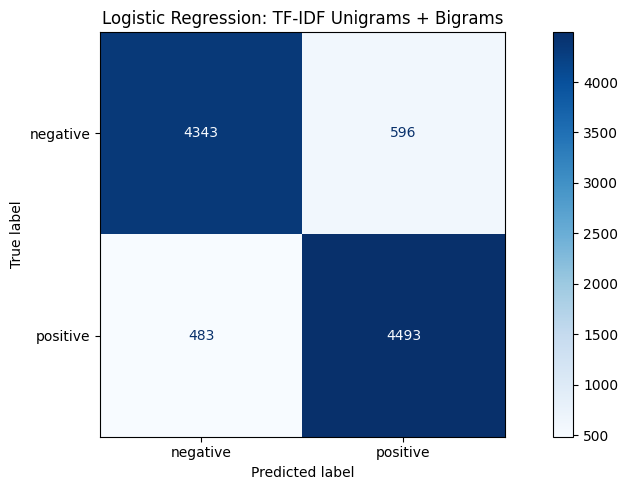

In [32]:
ConfusionMatrixDisplay.from_predictions(y_test, best_predictions, labels=["negative", "positive"], cmap="Blues")
plt.title(f"{best_model_name}: {best_representation}")
plt.tight_layout()
plt.show()

Rows are actual classes and columns are predictions. Negative→positive errors are false positives; positive→negative errors are false negatives. The next section inspects actual reviews instead of assuming why a prediction failed.

## 13. Part K — Correct predictions and error analysis

In [33]:
errors = df.loc[test_idx, ["review", "sentiment", "word_count"]].copy()
errors.columns = ["Review", "Actual", "Word count"]
errors["Predicted"] = best_predictions
errors["Correct?"] = errors["Actual"].eq(errors["Predicted"])
display(errors.groupby("Correct?")["Word count"].agg(["count", "mean", "median"]))

,count,mean,median
Correct?,,,
False,1079,223.806302,170.0
True,8836,233.577750,173.0


In [34]:
correct_examples = errors[errors["Correct?"]].sample(10, random_state=SEED).copy()
incorrect_examples = errors[~errors["Correct?"]].sample(10, random_state=SEED).copy()
selected_examples = pd.concat([correct_examples, incorrect_examples])
display(selected_examples[["Review", "Actual", "Predicted", "Correct?"]])

,Review,Actual,Predicted,Correct?
9639,"What is supposed to be a simple generic mystery plot involving a dead philanthropist is, in fact, a head-ache inducing tale about a bunch of characters (the only big actor bein...",negative,negative,True
17176,"Scandinavians are pretty good at making me laugh at the drab nothingness of my soulless life, huh.<br /><br />The film-making here was incredibly meticulous, every piece of fra...",positive,positive,True
34746,"So this made for TV film scores only a 7.6 on this site? Bah! Humbug! Without question this 1984 version of Dickens' classic tale is the best ever made. And yes, the Hound has ...",positive,positive,True
17331,"The Good Earth follows the life a slave girl and a poor farmer in China. The movie is based on the novel by Pearl S. Buck. The story is great, but I hated that they decided to ...",negative,negative,True
19375,I saw a lot films about Charles Dickens' Christmas Carol. But this one is the best of all! There is an atmosphere which is exactly the same as in the book. The actors (George C...,positive,positive,True
5936,"Something somewhere must have terribly gone wrong right at the time when the director was perceiving this plot. The movie, that was supposed to be the remake of one of the most...",negative,negative,True
6810,"some people think that the second series was where scooby was ruined..i disagree totally.the shows quality did not go up or down and scrappy ,win my opinion,as a very good chre...",positive,positive,True
33794,I was lucky enough to have seen this on a whim during a film festival and was smacked so hard with what I saw I returned the next night for its second of three screenings. A fu...,positive,positive,True
20380,"Three of the things you can say about Spalding Gray are: he certainly marched to the beat of his own ""drummer;"" he was never at a loss for words; and he obviously felt that tho...",positive,positive,True
15426,"Sending the Critters to space does seem like an entertaining idea, but was there really any need for a third film much less this fourth one? A film with Brad Dourif can't be al...",negative,negative,True


### Review-specific interpretation
The following table links each selected prediction to its strongest active feature evidence. These are model-based explanations, not proof of the reviewer’s intent. A separate qualitative discussion follows. The manually written notes below refer to the fixed review indices from this dataset and split.

In [35]:
feature_names = best_pipeline.named_steps["vectorizer"].get_feature_names_out()
model = best_pipeline.named_steps["model"]
if hasattr(model, "coef_"):
    feature_weights = model.coef_[0]
else:
    feature_weights = model.feature_log_prob_[1] - model.feature_log_prob_[0]
assert list(model.classes_) == ["negative", "positive"]

In [36]:
review_notes = {
    9639: 'Direct criticism of the plot, characters, and acting supports the negative label; the closing joke does not reverse the verdict.',
    17176: "Words about emptiness describe the film's subject, while praise for meticulous filmmaking and relatable humor supports the positive verdict.",
    34746: 'The reviewer explicitly calls this version the best and praises the cast, costumes, and music; criticism mostly concerns another adaptation.',
    17331: 'This is mixed sentiment: praise for the story is outweighed by explicit criticism of casting and accents.',
    19375: 'A short, clearly positive review praises the atmosphere and actors. Limited broadcast availability is not criticism of the film.',
    5936: 'Direct criticism of editing and direction plus the refusal to watch again makes the negative stance clear.',
    6810: 'The reviewer defends the show and calls it superb. Positive signals remain despite misspellings such as chrecter and Intriguded.',
    33794: 'Violent-sounding words describe satire, but the reviewer praises originality, refreshment, and renewed hope.',
    20380: 'Although the subject is called strange, the review praises his talent and relevance. The numeric rating is removed by cleaning.',
    15426: 'A long plot summary and some cast praise coexist with clear disappointment about a tired sequel and missed potential.',
}

In [37]:
review_notes.update({
    2144: 'Mixed sentiment and target confusion: praise concerns Vivian Wu and a different film, DINNER RUSH. The final sentence rejects ENCRYPT.',
    4680: 'Negative-sounding story words such as traitor, lying, wronged, and rage describe characters and action; the reviewer calls the adaptation satisfying and rewarding.',
    5897: 'Laughter is ridicule, not praise. The reviewer mocks unrealistic action and hack writing; a lexical model can mistake amusement for approval.',
    2232: 'Some praise for Stewart and early scenes is followed by criticism of a lost story and dramatic cliches. Mixed sentiment obscures the overall negative verdict.',
    535: 'The negative stance is explicit: vile, turd, and trash. Genre vocabulary and less-common insults are plausible issues, but the exact cause requires the feature evidence, not a guessed explanation.',
    43682: 'Horror-specific praise for gore and shocking scenes competes with lame acting and a weak script. The positive recommendation and 8/10 rating clarify intent, but numeric ratings are removed.',
    41089: 'Historical discussion dominates the review. The brief assessment is mixed and indirect, so positive phrases such as quite good can obscure its negative label.',
    21116: 'The phrase As actors, they were wonderful musicians is indirect criticism. Good music and biographical details do not cancel complaints about acting and the movie.',
    30587: "The quoted promotional phrase world's funniest human is not the reviewer's opinion. The actual verdict is dull and a bore, which a short review should make clear.",
    9661: 'A long review mixes background, criticism, praise, and later updates. Failed pilot and too bad can mislead, while praise for casting and a sincere adaptation supports the positive label.',
})

In [38]:
def explain_review(row):
    vector = best_pipeline.named_steps["vectorizer"].transform([preprocess_text(row["Review"])])
    contributions = vector.data * feature_weights[vector.indices]
    order = np.argsort(np.abs(contributions))[-5:][::-1]
    evidence = [f"{feature_names[vector.indices[i]]} ({contributions[i]:+.2f})" for i in order]
    result = "Correct prediction" if row["Correct?"] else "Evidence conflicts with the label"
    return review_notes.get(row.name, result) + "; strongest feature contributions: " + ", ".join(evidence)
selected_examples["Your Analysis"] = selected_examples.apply(explain_review, axis=1)
with pd.option_context("display.max_colwidth", None):
    display(selected_examples[["Review", "Actual", "Predicted", "Correct?", "Your Analysis"]])

Review    Actual Predicted  Correct?                                                                                                                                                                                                                                                                                                          Your Analysis
9639                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               What is supposed to be a simple generic mystery plot involving a dead philanthropist is, in fact, a head-ache inducing tale about a bunch of char

In [39]:
category_patterns = {"Negation": r"\b(?:not|no|never)\b|n't", "Sarcasm candidates": r"yeah right|as if|supposed to|what a masterpiece", "Mixed sentiment candidates": r"\b(?:but|although|however|despite)\b", "Ambiguous language": r"\b(?:okay|average|perhaps|maybe|fine)\b", "Domain-specific words": r"\b(?:plot|screenplay|cinematography|genre|horror)\b", "Spelling error candidates": r"\b(?:teh|recieve|definately|awfull|goood)\b"}
category_rows = []
for category, pattern in category_patterns.items():
    mask = errors["Review"].str.contains(pattern, case=False, regex=True)
    subset = errors[mask]
    category_rows.append({"Category": category, "Candidates": len(subset), "Errors": (~subset["Correct?"]).sum(), "Error rate": (~subset["Correct?"]).mean()})
long_reviews = errors[errors["Word count"] >= df.loc[train_idx, "word_count"].quantile(0.90)]
category_rows.append({"Category": "Long reviews (training 90th percentile)", "Candidates": len(long_reviews), "Errors": (~long_reviews["Correct?"]).sum(), "Error rate": (~long_reviews["Correct?"]).mean()})
display(pd.DataFrame(category_rows))

,Category,Candidates,Errors,Error rate
0,Negation,8629,948,0.109862
1,Sarcasm candidates,761,71,0.093298
2,Mixed sentiment candidates,7573,862,0.113825
3,Ambiguous language,2047,242,0.118222
4,Domain-specific words,3170,304,0.095899
5,Spelling error candidates,13,0,0.000000
6,Long reviews (training 90th percentile),1050,95,0.090476


In [40]:
training_counts = Counter(" ".join(df.loc[train_idx, "cleaned_text"]).split())
def rare_share(text):
    words = preprocess_text(text).split()
    return sum(training_counts[word] <= 2 for word in words) / max(len(words), 1)
errors["Rare token share"] = errors["Review"].map(rare_share)
display(errors.groupby("Correct?")["Rare token share"].mean().to_frame())
display(errors[~errors["Correct?"]].nlargest(3, "Rare token share")[["Review", "Actual", "Predicted", "Rare token share"]])

,Rare token share
Correct?,
False,0.016734
True,0.014645


,Review,Actual,Predicted,Rare token share
27161,"What about DJ Cash Money??? This film fails in part by not covering the mid to late 80s. There was only a small mention of DJ Cheese in 86.<br /><br />Also, it's Grandmixer ""DS...",positive,negative,0.176471
41089,"According to ""Lucien Rebatet"" in his ""Histoire de la Musique"" (Robert Lafont, BOUQUINS 1973 page 338) Beethoven's character was not very compatible with women. He had quite a n...",negative,positive,0.160714
34823,"Each year the company called Nu produces couple of ""action packed"", ""full of suspense"" movies. This little nugget, called Shadowcaster III(Until I visited this site I wasn't av...",negative,positive,0.122807


**Failure categories:** Pattern counts are candidate subsets, not verified linguistic labels or causal explanations. Sarcasm and spelling especially require manual judgment; a zero count does not prove absence.

| Category | Why the model can fail |
|---|---|
| Negation | A unigram model treats `good` as positive despite `not`; even bigrams miss long-distance negation. |
| Sarcasm | Literally positive vocabulary can communicate criticism, requiring context and intent. |
| Mixed sentiment | Praise for acting and criticism of the story can compete; the final verdict may be overwhelmed. |
| Long reviews | Many details dilute a brief decisive opinion; sparse models do not track the argument. |
| Ambiguous language | `Fine` or `average` may be neutral, but only positive and negative labels exist. |
| Domain-specific words | `Unpredictable` may praise a thriller while criticizing another product; associations are domain dependent. |
| Spelling errors | Misspellings may not match the vocabulary; character n-grams could help. |
| Rare words | Low-frequency or unseen terms have weak evidence or are excluded by the 5,000-feature cap. |

Synthetic diagnostic examples below directly exercise all eight categories; they are **not** counted as held-out accuracy or replacements for the 20 real examples above.

In [41]:
probes = pd.DataFrame({"Category": ["Negation", "Sarcasm", "Mixed sentiment", "Long review", "Ambiguous language", "Domain vocabulary", "Spelling errors", "Rare words"], "Review": ["This movie was not good at all.", "A masterpiece of wasting two hours of my life. Bravo.", "The acting was great, but the story was awful and I hated the movie.", "The movie has actors, scenes, music and a story. " * 80 + "Overall, I hated it.", "It was fine, I suppose, neither good nor bad.", "A chilling and unsettling horror film with excellent cinematography.", "I luvd this moovie, it was amazzing and goood.", "An ineffably splendiferous cinematic triumph."], "Intended sentiment": ["negative", "negative", "negative", "negative", "ambiguous / neutral", "positive", "positive", "positive"]})
probes["Predicted"] = best_pipeline.predict(probes["Review"].map(preprocess_text))
display(probes)

,Category,Review,Intended sentiment,Predicted
0,Negation,This movie was not good at all.,negative,negative
1,Sarcasm,A masterpiece of wasting two hours of my life. Bravo.,negative,negative
2,Mixed sentiment,"The acting was great, but the story was awful and I hated the movie.",negative,negative
3,Long review,"The movie has actors, scenes, music and a story. The movie has actors, scenes, music and a story. The movie has actors, scenes, music and a story. The movie has actors, scenes,...",negative,negative
4,Ambiguous language,"It was fine, I suppose, neither good nor bad.",ambiguous / neutral,negative
5,Domain vocabulary,A chilling and unsettling horror film with excellent cinematography.,positive,positive
6,Spelling errors,"I luvd this moovie, it was amazzing and goood.",positive,positive
7,Rare words,An ineffably splendiferous cinematic triumph.,positive,positive


## 14. Part L — Interpretability of the best main-grid linear model
Choose the highest-validation-F1 Logistic Regression or Linear SVM model. If the overall winner is Naive Bayes, this is a separately identified linear model.

In [42]:
linear_row = validation_results[validation_results["Model"].isin(["Logistic Regression", "Linear SVM"])].iloc[0]
linear_pipeline = fitted_pipelines[(linear_row["Representation"], linear_row["Model"])]
linear_features = linear_pipeline.named_steps["vectorizer"].get_feature_names_out()
weights = linear_pipeline.named_steps["model"].coef_[0]
positive_order = np.argsort(weights)[-20:][::-1]
negative_order = np.argsort(weights)[:20]
print("Interpreted model:", linear_row["Representation"], linear_row["Model"])
display(pd.DataFrame({"Positive feature": linear_features[positive_order], "Positive weight": weights[positive_order], "Negative feature": linear_features[negative_order], "Negative weight": weights[negative_order]}))

Interpreted model: TF-IDF Unigrams + Bigrams Logistic Regression


,Positive feature,Positive weight,Negative feature,Negative weight
0,excellent,6.824546,worst,-8.943097
1,great,6.474887,awful,-7.537041
2,perfect,5.307923,bad,-6.985435
3,amazing,5.198518,waste,-6.542924
4,best,5.071633,boring,-6.369573
5,favorite,4.724640,poor,-5.523361
6,wonderful,4.719536,terrible,-5.285199
7,brilliant,4.287793,horrible,-5.080960
8,hilarious,4.250662,dull,-4.978001
9,loved,4.234688,fail,-4.964935


Positive coefficients push the decision toward positive sentiment; negative coefficients push toward negative sentiment. Strong weights reflect predictive training associations, not universal meanings or causal effects. Words such as `excellent` can discriminate labels; `the` appears across both classes and is usually uninformative (and is removed by this pipeline). Correlated features, vocabulary limits, and regularization also affect weights. The intercept and all active features jointly determine each decision.

## 15. Part M — Option 3: Gradio sentiment analyzer
The app accepts raw review text and returns sentiment plus probability scores. Use the highest-validation-F1 Logistic Regression candidate because it provides probabilities directly. If a different model won overall, this app is explicitly a different candidate. Probabilities are model estimates, not guaranteed or calibrated confidence.

In [43]:
import gradio as gr
app_row = validation_results[validation_results["Model"].eq("Logistic Regression")].iloc[0]
app_pipeline = fitted_pipelines[(app_row["Representation"], app_row["Model"])]
print("App model:", app_row["Representation"], app_row["Model"])

App model: TF-IDF Unigrams + Bigrams Logistic Regression


In [44]:
def predict_sentiment(review):
    cleaned = preprocess_text(review)
    if not cleaned:
        return "Please enter a review containing words.", {}
    probabilities = app_pipeline.predict_proba([cleaned])[0]
    classes = app_pipeline.named_steps["model"].classes_
    label = classes[np.argmax(probabilities)]
    confidence = probabilities.max()
    return f"Predicted sentiment: {label.title()} | Confidence: {confidence:.1%}", dict(zip(classes, probabilities.tolist()))
print(predict_sentiment("This movie was surprisingly good and entertaining."))

('Predicted sentiment: Positive | Confidence: 98.8%', {'negative': 0.012290104757481046, 'positive': 0.987709895242519})


In [45]:
demo = gr.Interface(fn=predict_sentiment, inputs=gr.Textbox(lines=5, label="Movie review"), outputs=[gr.Textbox(label="Prediction"), gr.Label(label="Estimated probabilities")], title="IMDb Sentiment Analyzer", examples=[["This movie was surprisingly good and entertaining."], ["The plot was boring and I did not enjoy it."]], flagging_mode="never")

In [46]:
# Uncomment to open the interactive app in your notebook.
# demo.launch(share=False)

## 16. Final analysis — Report within the notebook
The following report summarizes the saved execution; rerunning with different data or settings requires updating these written findings. It covers the requested problem statement, dataset, methodology, comparisons, error analysis, and conclusions in approximately 1–2 pages of prose.

In [47]:
ab = ablation_results.set_index("Preprocessing")["Validation F1"]
stop_delta = ab["Cleaning + stopwords"] - ab["Basic cleaning only"]
stem_delta = ab["Cleaning + stopwords + stemming"] - ab["Cleaning + stopwords"]
lemma_delta = ab["Cleaning + stopwords + lemmatization"] - ab["Cleaning + stopwords"]
clean_delta = ab["Basic cleaning only"] - ab["Raw text"]
deltas = {"basic cleaning": clean_delta, "stopword removal": stop_delta, "stemming": stem_delta, "lemmatization": lemma_delta}
largest_step = max(deltas, key=lambda key: abs(deltas[key]))
val_pivot = validation_results.pivot(index="Model", columns="Representation", values="Validation F1")
bigram_bow = val_pivot["BoW Unigrams + Bigrams"] - val_pivot["BoW Unigrams"]
bigram_tfidf = val_pivot["TF-IDF Unigrams + Bigrams"] - val_pivot["TF-IDF Unigrams"]
tfidf_uni = val_pivot["TF-IDF Unigrams"] - val_pivot["BoW Unigrams"]
tfidf_bi = val_pivot["TF-IDF Unigrams + Bigrams"] - val_pivot["BoW Unigrams + Bigrams"]

### Problem, data, and methodology
The task was to classify customer-style movie reviews as positive or negative while investigating the entire traditional NLP pipeline. The uploaded IMDb dataset supplies review text and sentiment labels. After removing missing or empty reviews, duplicate normalized text, and conflicting duplicate labels, 49,574 reviews remained. The original classes were balanced, so accuracy is informative here, but positive-class precision, recall, F1, macro-F1, and the confusion matrix provide a fuller evaluation. Results apply to this review dataset, not automatically to other products, languages, or social-media text.

One fixed stratified 80/20 train–test split reserved 9,915 reviews for testing. An inner split of the training data supplied fitting and validation subsets. All models used these same rows. Each vectorizer learned its vocabulary and any IDF weights only from its fitting partition. The experiment compared four representations—BoW and TF-IDF, each with unigrams or unigram+bigrams—using Logistic Regression, Multinomial Naive Bayes, and Linear SVM. Model selection used validation F1, followed by refitting on the complete training portion. The final test table is descriptive and was not used to change the chosen model.

### Preprocessing findings
The pipeline lowercased text, decoded HTML entities, removed tags and URLs, expanded common negative contractions, tokenized alphabetic words, removed selected stopwords, and lemmatized. Negation words were retained because removing them can reverse meaning. The controlled ablation measured these approximate validation-F1 changes: basic cleaning +0.0065, stopword removal -0.0084, stemming +0.0003, and lemmatization -0.0008. Positive changes mean improvement; negative changes mean deterioration. The largest absolute measured change was for stopword removal (-0.0084). These comparisons isolate each stated change relative to its appropriate baseline, rather than attributing all differences to one step.

Thus stopword removal did not improve validation F1 in this setup. Stemming improved performance over cleaned, stopword-filtered text without normalization, while lemmatization did not improve it. Lemmatization remains easier to interpret, but our simple noun-default implementation does not normalize every grammatical form. Basic cleaning alone had the strongest ablation score (validation F1 0.8930), higher than the fixed lemmatized main grid. It was not promoted to a new tested model in this run. No method should be declared universally superior from one split. Preserving punctuation, ratings, or emoji could also recover information discarded by this pipeline.

### Representations and models
The best main-grid combination was **TF-IDF Unigrams + Bigrams with Logistic Regression**, with validation F1 0.8838. After refitting, its test accuracy was 0.8912, precision 0.8829, recall 0.9029, and F1 0.8928. Logistic Regression jointly learns regularized feature weights; TF-IDF reduces common-word influence and bigrams add local context. These are plausible strengths, not a causal explanation established by this experiment. The highest observed test F1 belonged to TF-IDF Unigrams + Bigrams with Logistic Regression (0.8928); the lowest belonged to BoW Unigrams with Naive Bayes (0.8388). These test rankings are reported for the assignment, not used for further tuning.

Averaged across the three classifiers, adding bigrams changed validation F1 by +0.0031 for BoW and +0.0037 for TF-IDF. Comparing matching n-gram settings, TF-IDF minus BoW averaged +0.0190 for unigrams and +0.0197 for unigram+bigrams. The detailed table shows whether individual classifiers follow those averages. Bigrams encode short phrases such as “not good,” but a 5,000-feature cap means some unigram features can be displaced. TF-IDF reduces the influence of widely shared vocabulary, while counts retain repetition more directly. No embedding or transformer result is claimed because the chosen advanced option was a Gradio application.

### Errors, interpretation, and limitations
The notebook includes ten correct and ten incorrect real test reviews, with label, prediction, and their strongest active feature contributions. Those contributions explain the fitted decision, but cannot establish the author's intent. Additional candidate-group analysis examines negation, mixed sentiment, long reviews, ambiguous wording, domain vocabulary, possible spelling errors, and rare terms. Sarcasm requires contextual interpretation and is not reliably identified by keywords. Synthetic diagnostic probes cover all eight failure categories separately from held-out evaluation.

The top positive and negative coefficients expose learned sentiment associations. Sparse linear methods can work well when lexical signals align with labels, but they lose document structure, negation scope, irony, and much of word order. Other limitations include English-only cleaning, imperfect lemmatization, discarded ratings, a fixed feature cap, one split, and possible near-duplicates that exact matching cannot remove. The application's probability scores are not calibrated reliability guarantees. Training scores above validation scores suggest fitting to training-specific patterns; comparing both helps identify this risk.

### Improvements
With more time, I would use repeated stratified validation, tune regularization and vocabulary size on training data, test character n-grams for spelling variation, and compare a POS-aware lemmatizer with lighter cleaning. Human review of errors would separate genuine label ambiguity from model failure. A later experiment could compare pretrained contextual embeddings or a fine-tuned transformer under the same evaluation protocol. For deployment, I would add probability calibration, an uncertain/neutral fallback, privacy-conscious monitoring, and a separate out-of-domain test set. Traditional models remain valuable because they are inexpensive, fast, and interpretable baselines.

## 17. Thinking questions
1. **Why can accuracy mislead on imbalanced data?** A model predicting the majority class for every input can score highly while never recognizing the minority class. Inspect per-class recall, precision, macro-F1, and confusion counts.
2. **Why is TF-IDF sparse?** A document contains only a small fraction of the corpus vocabulary; absent terms have zero weight.
3. **Why do more n-grams increase dimensionality?** There are many possible sequences, and most occur rarely. A feature cap limits storage but discards some candidates.
4. **Why can “The movie was not bad” be misclassified?** Unigrams lose the negation relationship; even bigrams may not have learned that this phrase often conveys mild praise.
5. **Why use traditional ML when transformers exist?** Sparse models need less compute, train quickly, are easier to inspect, and provide useful baselines when training data or deployment resources are limited.
6. **What does Bag-of-Words lose?** Unigram BoW loses word order, syntax, scope, speaker intent, and most contextual meaning while keeping term counts.
7. **How does order affect n-grams?** Unigrams ignore it; bigrams preserve adjacent pairs; trigrams preserve triples. None captures the complete sentence structure.
8. **Why is “excellent” useful but “the” often not?** “Excellent” can correlate with positive labels; “the” is common in both classes and usually has little discriminative value. Learned weights still depend on the dataset.
9. **How would you handle sarcasm in production?** Collect human-labeled sarcastic examples, evaluate contextual models and available conversational context, and route uncertain cases to review. No keyword rule reliably solves sarcasm.
10. **What changes with Positive/Neutral/Negative?** Obtain explicit neutral training labels, use stratified three-class splits and compatible multiclass estimators, report per-class and macro metrics, use a 3×3 confusion matrix, and show three probability scores. Low binary confidence alone is not a valid neutral label.

## 18. Assignment coverage checklist
| Requirement | Location |
|---|---|
| A: Records, columns, first 10, types, missing/empty/duplicates, balance, longest/shortest, questions | Section 02 |
| B: Reusable preprocessing, 10 original/cleaned examples, negation and task differences | Section 03 |
| C: NLP-library tokenization, token statistics, top 20 visualization, before/after stopwords | Section 04 |
| D: At least 20 stemming/lemmatization examples and explanations | Section 05 |
| E: Top 20 uni/bi/trigrams, bigram chart, contextual trade-offs | Section 06 |
| F–G: Two BoW and two TF-IDF configurations, feature counts, train/validation/test scores | Sections 08–11 |
| H–I: Three classifiers, same splits, comparison and trade-offs | Sections 07, 09, 11, 16 |
| J: Best-model metrics and confusion visualization | Section 12 |
| K: 10 correct and 10 incorrect reviews, analysis, eight failure categories | Section 13 |
| L: 20 positive and 20 negative linear-model features and explanation | Section 14 |
| M: Option 3 Gradio app with review input, sentiment, and confidence | Section 15 |
| Final 1–2 page analysis and all 10 thinking questions | Sections 16–17 |

Only a notebook is produced, as requested. The report content is included above, and the dataset remains in the original user-supplied ZIP.